In [1]:
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_core.messages import  HumanMessage
from rich import pretty,print
pretty.install()

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description='Query Arxiv Papers')


In [3]:
print(arxiv)

ArxivQueryRun(
    description='Query Arxiv Papers',
    api_wrapper=ArxivAPIWrapper(
        arxiv_search=<class 'arxiv.Search'>,
        arxiv_exceptions=(
            <class 'arxiv.ArxivError'>,
            <class 'arxiv.UnexpectedEmptyPageError'>,
            <class 'arxiv.HTTPError'>
        ),
        top_k_results=2,
        ARXIV_MAX_QUERY_LENGTH=300,
        continue_on_failure=False,
        load_max_docs=100,
        load_all_available_meta=False,
        doc_content_chars_max=500
    )
)

In [4]:
print(arxiv.invoke('Attention is all you need'))

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often 
attributed to the design of their multi-head attention layers. However, the extent to which attention is 
responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even 
necessary? Specifi

In [5]:
wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=3)
wikipedia = WikipediaQueryRun(api_wrapper=wikipedia_wrapper)

wikipedia.invoke('Albert Einstein')


'Page: Albert Einstein\nSummary: Albert Einstein (14 March 1879 – 18 April 1955) was a German-born theoretical physicist best known for developing the theory of relativity. Einstein also made important contributions to quantum theory. His mass–energy equivalence formula E = mc2, which arises from special relativity, has been called "the world\'s most famous equation". He received the 1921 Nobel Prize in Physics for "his services to theoretical physics, and especially for his discovery of the law of the photoelectric effect".\nBorn in the German Empire, Einstein moved to Switzerland in 1895, forsaking his German citizenship the following year. In 1897, at the age of seventeen, he enrolled in the mathematics and physics teaching diploma program at the Swiss federal polytechnic school in Zurich, graduating in 1900. He acquired Swiss citizenship a year later, which he kept for the rest of his life, and afterwards secured a permanent position at the Swiss Patent Office in Bern. In 1905, he 

In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_tavily.tavily_search import TavilySearch

tavily = TavilySearch()
tavily.invoke('First US soldiers to die in Iran conflict')


{
    'query': 'First US soldiers to die in Iran conflict',
    'response_time': 0.77,
    'follow_up_questions': None,
    'answer': None,
    'images': [],
    'results': [
        {
            'url': 'https://www.lemonde.fr/en/middle-east-crisis/article/2026/03/01/pentagon-announces-first-us-soldiers-killed-in-operation-against-iran_6750984_368.html',
            'title': 'Pentagon announces first US soldiers killed in operation against Iran',
            'content': 'The Pentagon said three US service members were killed and five others seriously wounded. Le Monde with AFP. Published on March 1, 2026, at 5:28',
            'score': 0.72884524,
            'raw_content': None
        },
        {
            'url': 'https://www.youtube.com/watch?v=KVoPQip3C84',
            'title': 'Pentagon identifies first US soldiers killed in Iran war - YouTube',
            'content': 'The Pentagon named four US soldiers killed in a drone strike on a military facility in Kuwait during the conf

In [8]:
tools = [arxiv,wikipedia,tavily]

In [9]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='openai/gpt-oss-20b')


In [10]:
llm.invoke('What is AI')


AIMessage(
    content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include:\n\n| Category | Examples | Typical Techniques |\n|----------|----------|--------------------|\n| **Perception** | Vision, speech, and language understanding | Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), Transformers |\n| **Reasoning & Planning** | Problem solving, decision making | Logic programming, search algorithms, probabilistic models |\n| **Learning** | Adapting from data | Supervised, unsupervised, reinforcement learning |\n| **Interaction** | Dialogue, user interfaces | Natural Language Processing (NLP), dialogue systems |\n\n### Core Concepts\n\n1. **Machine Learning (ML)** – The most common subset of AI, where models learn patterns from data.\n2. **Neural Networks** – Inspired by the brain’s structure; deep learning uses many layers to ex

In [11]:
superllm = llm.bind_tools(tools)

In [12]:
superllm.invoke('Tell me about Recent Israel Iran Conflict and latest news about the same')


AIMessage(
    content='',
    additional_kwargs={
        'reasoning_content': 'The user asks for recent Israel-Iran conflict and latest news. We need up-to-date info. We can use tavily_search to get recent news. We\'ll search "Israel Iran conflict latest news" with a recent time range. Then provide summary.',
        'tool_calls': [
            {
                'id': 'fc_fd452e35-8d93-4d13-990b-ad48ebbbbb9d',
                'function': {
                    'arguments': '{"query":"Israel Iran conflict latest news","search_depth":"advanced","time_range":"day"}',
                    'name': 'tavily_search'
                },
                'type': 'function'
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 90,
            'prompt_tokens': 410,
            'total_tokens': 500,
            'completion_time': 0.090056777,
            'completion_tokens_details': {'reasoning_tokens': 51},
            'prompt_time': 0.02116

In [13]:
from typing import Annotated,TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph import START,END,StateGraph


In [14]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

In [15]:
def start_call(state:State) -> State:
    return {'messages':[superllm.invoke(state['messages'])]} 

In [16]:
tool_node = ToolNode(tools)

In [17]:
graph = StateGraph(State)
graph.add_node('start_llm',start_call)
graph.add_node('tools',tool_node)

graph.add_edge(START,'start_llm')
graph.add_conditional_edges('start_llm',tools_condition)
graph.add_edge('tools','start_llm')

workflow = graph.compile()

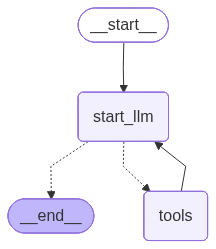

In [18]:
workflow

In [23]:
result = workflow.invoke({'messages':[HumanMessage(content='1706.03762')]})

In [25]:
print(result['messages'])

[
    HumanMessage(
        content='1706.03762',
        additional_kwargs={},
        response_metadata={},
        id='ab9b9b8e-f3f3-4f2f-885f-201905e6611a'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'reasoning_content': 'The user provided "1706.03762" which looks like an arXiv identifier. Likely they 
want to get information about the paper. We should use the arxiv function to retrieve details.',
            'tool_calls': [
                {
                    'id': 'fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd',
                    'function': {'arguments': '{"query":"1706.03762"}', 'name': 'arxiv'},
                    'type': 'function'
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 69,
                'prompt_tokens': 402,
                'total_tokens': 471,
                'completion_time': 0.069410917,
                'completion_tokens_details': {'reasoning_tokens': 42},
                'prompt_time': 0.008321279,
                'prompt_tokens_details': {'cached_tokens': 256},
                'queue_time': 0.043433061,
                'total_time': 0.077732196
            },
            'model_name': 'openai/gpt-oss-20b',
            'system_fingerprint': 'fp_80501ff3a1',
            'service_tier': 'on_demand',
            'finish_reason': 'tool_calls',
            'logprobs': None,
            'model_provider': 'groq'
        },
        id='lc_run--019cb830-1b0f-7ba2-9b9c-7502ec6d99a1-0',
        tool_calls=[
            {
                'name': 'arxiv',
                'args': {'query': '1706.03762'},
                'id': 'fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 402,
            'output_tokens': 69,
            'total_tokens': 471,
            'input_token_details': {'cache_read': 256},
            'output_token_details': {'reasoning': 42}
        }
    ),
    ToolMessage(
        content='Published: 2023-08-02\nTitle: Attention Is All You Need\nAuthors: Ashish Vaswani, Noam Shazeer, 
Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin\nSummary: The dominant 
sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder 
configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We 
propose a new simple network architecture, the Transformer, base',
        name='arxiv',
        id='7406370c-db4e-4e0a-a41f-5a277c55233c',
        tool_call_id='fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'reasoning_content': 'The user provided "1706.03762". That\'s an arXiv identifier. The assistant 
responded with the arxiv tool output. The user didn\'t ask a question. They might want the abstract. We should 
provide the abstract. The assistant already gave summary. Maybe provide full abstract. Let\'s fetch full abstract. 
Use arxiv again? The tool gave summary. We can provide abstract. Let\'s use arxiv to get abstract.',
            'tool_calls': [
                {
                    'id': 'fc_544ba16d-29d5-4a6d-915a-42a6a870086e',
                    'function': {'arguments': '{"query":"1706.03762 abstract"}', 'name': 'arxiv'},
                    'type': 'function'
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'completion_tokens': 111,
                'prompt_tokens': 547,
                'total_tokens': 658,
                'completion_time': 0.112037581,
                'completion_tokens_details': {'reasoning_tokens': 86},
                'prompt_time': 0.028980688,
                'prompt_tokens_details': None,
                'queue_time': 0.043466022,
          

In [27]:
for i in result['messages']:
    print(i.pretty_print())

================================ Human Message =================================

1706.03762


None

================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd)
 Call ID: fc_d64a5280-cf31-48b5-b170-3f45d2a36dfd
  Args:
    query: 1706.03762


None

================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


...

None

================================= Tool Message =================================
Name: tavily_search

{"query": "arXiv 1706.03762", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://arxiv.org/abs/1706.03762", "title": "[1706.03762] Attention Is All You Need - arXiv", "content": "[Skip to main content](https://arxiv.org/abs/1706.03762#content). *   [Login](https://arxiv.org/login). *   [Help Pages](https://info.arxiv.org/help). *   [About](https://info.arxiv.org/about). [Submitted on 12 Jun 2017 ([v1](https://arxiv.org/abs/1706.03762v1)), last revised 2 Aug 2023 (this version, v7)]. [View PDF](https://arxiv.org/pdf/1706.03762)[HTML (experimental)](https://arxiv.org/html/1706.03762v7). Cite as:[arXiv:1706.03762](https://arxiv.org/abs/1706.03762) [cs.CL]. (or [arXiv:1706.03762v7](https://arxiv.org/abs/1706.03762v7) [cs.CL] for this version). **[[v1]](https://arxiv.org/abs/1706.03762v1)** Mon, 12 Jun 2017 17:57:34 UTC (1,102 KB). **[[v2]](https://arxiv

None

================================== Ai Message ==================================

**arXiv 1706.03762 – “Attention Is All You Need”**

| Item | Details |
|------|---------|
| **Title** | *Attention Is All You Need* |
| **Authors** | Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin |
| **Submitted** | 12 Jun 2017 (v1) – last revised 2 Aug 2023 (v7) |
| **Subject** | Computer Science – Computation and Language (cs.CL) |
| **Abstract** | The dominant sequence‑to‑sequence models at the time relied on complex recurrent or convolutional encoder‑decoder architectures.  The authors propose a **purely attention‑based** architecture, the *Transformer*, that eliminates recurrence and convolution entirely.  The model uses multi‑headed self‑attention and a simple positional encoding scheme to capture sequence order.  On the WMT 2014 English‑German translation task the Transformer achieves a BLEU score of **28.4** (single‑model),

None

In [31]:
result['messages'][-1].content

'**arXiv\u202f1706.03762 – “Attention Is All You Need”**\n\n| Item | Details |\n|------|---------|\n| **Title** | *Attention Is All You Need* |\n| **Authors** | Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin |\n| **Submitted** | 12\u202fJun\u202f2017 (v1) – last revised 2\u202fAug\u202f2023 (v7) |\n| **Subject** | Computer Science – Computation and Language (cs.CL) |\n| **Abstract** | The dominant sequence‑to‑sequence models at the time relied on complex recurrent or convolutional encoder‑decoder architectures.  The authors propose a **purely attention‑based** architecture, the *Transformer*, that eliminates recurrence and convolution entirely.  The model uses multi‑headed self‑attention and a simple positional encoding scheme to capture sequence order.  On the WMT\u202f2014 English‑German translation task the Transformer achieves a BLEU score of **28.4** (single‑model), surpassing the best previous results while